# 5. Diversity analysis
In this notebook, we performed rarefaction, as well as alpha and beta diversity analyses.
### Import Packages

In [1]:
# Import all necessary packages
import os
import IPython
import pandas as pd
import matplotlib.pyplot as plt
import qiime2 as q2
from qiime2 import Visualization
import shutil
from datetime import datetime
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

### Set Working Directory
Ensure that the working directory is correctly set to the 'scripts' folder within the main project directory. 
Otherwise, the file paths used in this notebook may not work properly.

In [2]:
# The working directory should normally default to the 'scripts' folder. 
# If it doesn't, set it manually using the command below.
# os.chdir("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts")  # Adjust this path to match your folder structure.

# Verify that your working directory is the 'scripts' folder inside the main project directory (.../MicrobiomeAnalysis_TummyTribe/scripts)
cwd = os.getcwd()
if not cwd.endswith("MicrobiomeAnalysis_TummyTribe/scripts"):
    print("WARNING: The working directory is not set to the 'scripts' folder inside 'MicrobiomeAnalysis_TummyTribe'!")
    print("Current working directory:", cwd)
    print("Please set it manually using os.chdir().")
else:
    print(f"Working directory is correctly set to the 'scripts' folder (\"{cwd}\").")

Working directory is correctly set to the 'scripts' folder ("/home/jovyan/MicrobiomeAnalysis_TummyTribe/scripts").


In [3]:
# 3 - Data directories
metadata_dir = "../data/raw"
raw_data_dir = "../data/raw"
denoising_data_dir = "../data/processed/denoising"
taxonomy_data_dir = "../data/processed/taxonomy"
phylogeny_data_dir = "../data/processed/phylogeny"
diversity_data_dir = "../data/processed/diversity"
# Create the diversity folder

In [4]:
%%bash -s "$diversity_data_dir"
mkdir -p "$1"

### Workflow Overview

This notebook follows four main steps to analyze microbiome diversity:

**1. Alpha Rarefaction**

We generate alpha rarefaction curves to check how alpha diversity changes with sequencing depth. This helps confirm that our chosen rarefaction depth is reasonable.

**2. Diversity Analysis**

Using the selected sequencing depth, we run QIIME2’s core-metrics pipeline. This produces:

Alpha diversity values (Faith’s PD, Shannon, observed features, evenness)

Beta diversity distance matrices and PCoA results (UniFrac, Bray–Curtis, Jaccard)

**3. Visualization**

We view the QIIME2 .qzv files for both alpha and beta diversity results. These include group significance plots and emperor PCoA plots.

**4. Extra Analysis in Python**

We load the exported diversity results into Python and create custom plots (e.g., Faith’s PD vs. age by country) for more exploration.

## 1. Alpha Rarefaction

First, we perform alpha rarefaction to examine how sequencing depth affects within-sample diversity estimates (alpha diversity) and to help select an appropriate sampling depth.  

To do this, we need to determine the min_depth and max_depth values, which can be obtained by inspecting the feature table.


In [5]:
# Feature Table (if we decide to filter it before adjust this & could theoretically just import the visualization
! qiime feature-table summarize \
    --i-table $denoising_data_dir/dada2_table.qza \
    --m-sample-metadata-file $raw_data_dir/metadata.tsv \
    --o-visualization $denoising_data_dir/dada2_table.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/denoising/dada2_table.qzv


In [6]:
Visualization.load(f"{denoising_data_dir}/dada2_table.qzv")

<visualization: Visualization uuid: 408f5a04-2b5f-4350-9c52-7e7cd46fc722>

In my opinion, a minimum sampling depth of 1 provides a useful reference point, so I decided to keep it, even though it clearly doesn't make sense to sample below 5'000 reads based on our feature table. For the maximum depth, I chose 55'000, since we definitely do not want to lose more than 3/4 of our data. I adjusted the step size to 15 to provide more detailed information between the data points.

In [7]:
! qiime diversity alpha-rarefaction \
    --i-table $denoising_data_dir/dada2_table.qza \
    --p-max-depth 55000 \
    --p-steps 15 \
    --m-metadata-file $raw_data_dir/metadata.tsv \
    --o-visualization $diversity_data_dir/alpha-rarefaction.qzv

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/alpha-rarefaction.qzv


In [8]:
Visualization.load(f"{diversity_data_dir}/alpha-rarefaction.qzv")

<visualization: Visualization uuid: a34f7827-5098-454c-8e5d-e87653796c65>

## 2. Diversity Analysis

### 2.1 Setting Up the Analysis Parameters

These are the settings used for this diversity analysis. Here we define the rarefaction depth and optional filtering choices. Changing these values will affect the downstream core-metrics results.

In [32]:
# Pipeline parameters

# Rarefaction depth for core metrics
sampling_depth = 14000

# Optional sample filtering
enable_sample_filtering = False   # switch filtering on/off
filter_age_months = 4.0           # example: 4.0, 7.0, 10.0
filter_country = None             # example: "Russia", "Finland"
filter_milk_type = None           # example: "bd", "fd"

# Input files
table_raw = f"{denoising_data_dir}/dada2_table.qza"
tree_qza  = f"{phylogeny_data_dir}/sepp-tree.qza"
metadata  = f"{metadata_dir}/metadata.tsv"


Based on the filtering settings above, we create a short label and a folder where all outputs from this run will be stored. This helps to keep different runs organized.

In [33]:
# Build a short label describing the filtering settings

filter_label_parts = []

if enable_sample_filtering:
    if filter_age_months:
        filter_label_parts.append(f"age-{filter_age_months}")
    if filter_country:
        filter_label_parts.append(f"country-{filter_country}")
    if filter_milk_type:
        filter_label_parts.append(f"milk-{filter_milk_type}")

# If nothing was added, mark it as "no-filter"
filter_label = "_".join(filter_label_parts) if filter_label_parts else "no-filter"

# Directory for storing all results of this run
run_dir = f"{diversity_data_dir}/depth-{sampling_depth}_{filter_label}"

!mkdir {run_dir}
print("Run directory:", run_dir)

Run directory: ../data/processed/diversity/depth-14000_no-filter


If filtering is turned on, samples are selected using metadata conditions (age, country, or milk type). Otherwise, we use the full table. The filtered or unfiltered table is then passed to the main diversity pipeline.

In [34]:
# Apply sample filtering based on metadata (if activated)

if enable_sample_filtering:
    print("Filtering enabled...")

    filtered_table = f"{run_dir}/filtered_table.qza"
    where_conditions = []

    # Add conditions depending on what the user set
    if filter_age_months is not None:
        where_conditions.append(f"age_months = {filter_age_months}")
    if filter_country is not None:
        where_conditions.append(f"geo_location_name = '{filter_country}'")
    if filter_milk_type is not None:
        where_conditions.append(f"diet_milk = '{filter_milk_type}'")

    # Combine everything into a single WHERE statement
    where_sql = " AND ".join(where_conditions)
    print("WHERE:", where_sql)

    # Run QIIME2 filtering
    !qiime feature-table filter-samples \
        --i-table {table_raw} \
        --m-metadata-file {metadata} \
        --p-where "{where_sql}" \
        --o-filtered-table {filtered_table}

    table_for_run = filtered_table

else:
    print("No filtering applied.")
    table_for_run = table_raw

No filtering applied.


### 2.2 Running Alpha and Beta Analysis

In this step we run QIIME2’s core-metrics-phylogenetic pipeline.
This calculates all standard diversity metrics (alpha and beta) at the chosen rarefaction depth.
The results are stored inside the run directory so we can generate visualizations later.

In [35]:
print("Running core metrics...")

!qiime diversity core-metrics-phylogenetic \
  --i-table {table_for_run} \
  --i-phylogeny {tree_qza} \
  --m-metadata-file {metadata} \
  --p-sampling-depth {sampling_depth} \
  --output-dir {run_dir}/core_metrics

Running core metrics...
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved FeatureTable[Frequency] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/rarefied_table.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/faith_pd_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/observed_features_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/shannon_vector.qza
Saved SampleData[AlphaDiversity] to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/evenness_vector.qza
Saved DistanceMatrix to: ../data/processed/d

After the core metrics are computed, we generate the corresponding alpha and beta diversity visualizations.
These include group significance tests for alpha metrics and emperor plots for the beta diversity PCoA results.

In [36]:
print("Generating alpha & beta visualizations...")

# Alpha diversity visualizations
alpha_vis_commands = [
    ("faith_pd_vector.qza",           "faith-pd-group-significance.qzv"),
    ("shannon_vector.qza",            "shannon-group-significance.qzv"),
    ("observed_features_vector.qza",  "observed-features-group-significance.qzv"),
    ("evenness_vector.qza",           "evenness-group-significance.qzv")
]

for infile, outfile in alpha_vis_commands:
    input_path = f"{run_dir}/core_metrics/{infile}"
    output_path = f"{run_dir}/core_metrics/{outfile}"
    
    if os.path.exists(input_path):
        !qiime diversity alpha-group-significance \
            --i-alpha-diversity {input_path} \
            --m-metadata-file {metadata} \
            --o-visualization {output_path}

print("Finished alpha visualizations!")


# Beta diversity emperor plots
beta_vis_commands = [
    ("unweighted_unifrac_pcoa_results.qza", "unweighted_unifrac_emperor.qzv"),
    ("weighted_unifrac_pcoa_results.qza",   "weighted_unifrac_emperor.qzv"),
    ("jaccard_pcoa_results.qza",            "jaccard_emperor.qzv"),
    ("bray_curtis_pcoa_results.qza",        "bray_curtis_emperor.qzv")
]

for pcoa_file, vis_file in beta_vis_commands:
    pcoa_path = f"{run_dir}/core_metrics/{pcoa_file}"
    output_path = f"{run_dir}/core_metrics/{vis_file}"
    
    if os.path.exists(pcoa_path):
        !qiime emperor plot \
            --i-pcoa {pcoa_path} \
            --m-metadata-file {metadata} \
            --o-visualization {output_path}

print("Finished beta visualizations!")


Generating alpha & beta visualizations...
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/faith-pd-group-significance.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Saved Visualization to: ../data/processed/diversity/depth-14000_no-filter/core_metrics/shannon-group-significance.qzv
/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: Us

### 2.3 Organizing Alpha and Beta Diversity Outputs

After generating the core metrics and visualizations, we sort the outputs into separate folders for alpha and beta diversity.
This keeps the run directory clean and makes it easier to find the files later.

In [37]:
# Create folders for storing metrics and visualizations

alpha_metrics_dir = f"{run_dir}/alpha/metrics"
alpha_vis_dir     = f"{run_dir}/alpha/visualizations"
beta_metrics_dir  = f"{run_dir}/beta/metrics"
beta_vis_dir      = f"{run_dir}/beta/visualizations"

# Make the directories if they don't already exist
for d in [alpha_metrics_dir, alpha_vis_dir, beta_metrics_dir, beta_vis_dir]:
    os.makedirs(d, exist_ok=True)

Now we move the alpha diversity results (both the numeric vectors and the QZV visualizations) into the corresponding folders.

In [38]:
# Move alpha diversity artifacts (metrics)
alpha_files = [
    "faith_pd_vector.qza",
    "shannon_vector.qza",
    "observed_features_vector.qza",
    "evenness_vector.qza"
]

for fname in alpha_files:
    src = f"{run_dir}/core_metrics/{fname}"
    if os.path.exists(src):
        shutil.move(src, f"{alpha_metrics_dir}/{fname}")

# Move alpha diversity visualizations
for _, vis_name in alpha_vis_commands:
    src = f"{run_dir}/core_metrics/{vis_name}"
    if os.path.exists(src):
        shutil.move(src, f"{alpha_vis_dir}/{vis_name}")


We do the same for beta diversity: distance matrices, PCoA results, and their emperor plots.

In [39]:
# Move beta diversity artifacts (distance matrices + PCoA files)
beta_files = [
    "unweighted_unifrac_distance_matrix.qza",
    "unweighted_unifrac_pcoa_results.qza",
    "weighted_unifrac_distance_matrix.qza",
    "weighted_unifrac_pcoa_results.qza",
    "bray_curtis_distance_matrix.qza",
    "bray_curtis_pcoa_results.qza",
    "jaccard_distance_matrix.qza",
    "jaccard_pcoa_results.qza"
]

for fname in beta_files:
    src = f"{run_dir}/core_metrics/{fname}"
    if os.path.exists(src):
        shutil.move(src, f"{beta_metrics_dir}/{fname}")

# Move beta emperor visualizations
for _, vis_name in beta_vis_commands:
    src = f"{run_dir}/core_metrics/{vis_name}"
    if os.path.exists(src):
        shutil.move(src, f"{beta_vis_dir}/{vis_name}")

The rarefied table is still useful, so we keep it in the main run directory.
After that, we delete the leftover core_metrics/ folder to reduce clutter.

In [40]:
# Move rarefied table to the run directory (keep this file)
rarefied_table = f"{run_dir}/core_metrics/rarefied_table.qza"
if os.path.exists(rarefied_table):
    shutil.move(rarefied_table, run_dir)

# Remove the now-empty core_metrics folder
!rm -r {run_dir}/core_metrics

### Optional Cleanup: Remove an Old Run Directory

This block is optional. If you want to re-run the pipeline from scratch with the same parameters, you can delete the existing run directory first. The code is commented out to avoid accidentally removing data.

In [18]:
# ======================================================
# DELETE RUN DIRECTORY 
# ======================================================
# Uncomment the lines below to delete the entire run_dir.
# This is useful if you want to re-run the pipeline cleanly
# with the same sampling depth or filters.
# ======================================================

# folder_to_delete = run_dir
# folder_to_delete = f"{diversity_data_dir}/depth-10000_no-filter"

# if os.path.exists(folder_to_delete):
#     print("Fast deletion with verbose output...\n")
#     !rm -rfv {folder_to_delete}
#     print("Directory deleted.")
# else:
#     print("Unsafe path — aborting.")

## 3. Visualize Results of Diversity Analysis

Here we load the .qzv files that were generated in the previous steps.
You can switch the folder paths if you want to inspect results from a different run.
Only a few visualizations are shown by default; others can be uncommented if needed

In [41]:
# Paths to the visualization folders
# (you can replace these with another run if you want)

alpha_to_visualize = alpha_vis_dir
# alpha_to_visualize = f"{diversity_data_dir}/depth-10000_no-filter/alpha/visualizations"

beta_to_visualize = beta_vis_dir
# beta_to_visualize =  f"{diversity_data_dir}/depth-10000_no-filter/beta/visualizations"

In [42]:
# --- Alpha diversity visualizations ---

# Visualization.load(f"{alpha_to_visualize}/faith-pd-group-significance.qzv")
# Visualization.load(f"{alpha_to_visualize}/shannon-group-significance.qzv")
# Visualization.load(f"{alpha_to_visualize}/observed-features-group-significance.qzv")
Visualization.load(f"{alpha_to_visualize}/evenness-group-significance.qzv")

<visualization: Visualization uuid: 4f4da8d0-ffc7-4184-95b1-71d5739daf82>

In [43]:
# --- Beta diversity emperor plots ---

Visualization.load(f"{beta_to_visualize}/unweighted_unifrac_emperor.qzv")
# Visualization.load(f"{beta_to_visualize}/weighted_unifrac_emperor.qzv")
# Visualization.load(f"{beta_to_visualize}/jaccard_emperor.qzv")
# Visualization.load(f"{beta_to_visualize}/bray_curtis_emperor.qzv")

<visualization: Visualization uuid: e27eeba5-8ce1-4add-a1f7-bedaf7a8c3a8>

## 4. Extra analysis: Faith’s PD vs. age by country --> maybe delete this?

In this final part, we take the alpha diversity results that were generated by QIIME2 and explore them more closely in Python.
We focus on Faith’s phylogenetic diversity (Faith’s PD), which reflects how evolutionarily diverse each sample is. Since the infants in this study were sampled at different ages, we want to see how Faith’s PD changes over time.

We load the metadata together with the exported Faith’s PD values, merge them into one table, and then make a line plot of Faith’s PD vs. age (in months). The data are grouped by country so we can compare how the diversity develops across different populations.


In [44]:
! qiime tools export \
  --input-path $alpha_metrics_dir/faith_pd_vector.qza \
  --output-path $alpha_metrics_dir/faith_pd_vector_export

/opt/conda/lib/python3.10/site-packages/unifrac/__init__.py:9: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  import pkg_resources
Exported ../data/processed/diversity/depth-14000_no-filter/alpha/metrics/faith_pd_vector.qza as AlphaDiversityDirectoryFormat to directory ../data/processed/diversity/depth-14000_no-filter/alpha/metrics/faith_pd_vector_export


/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to get_group in a future version of pandas. Pass `(name,)` instead of `name` to silence this warning.
  data_subset = grouped_data.get_group(pd_key)
/opt/conda/lib/python3.10/site-packages/seaborn/_oldcore.py:1075: FutureWarning: When grouping with a length-1 list-like, you will need to pass a length-1 tuple to 

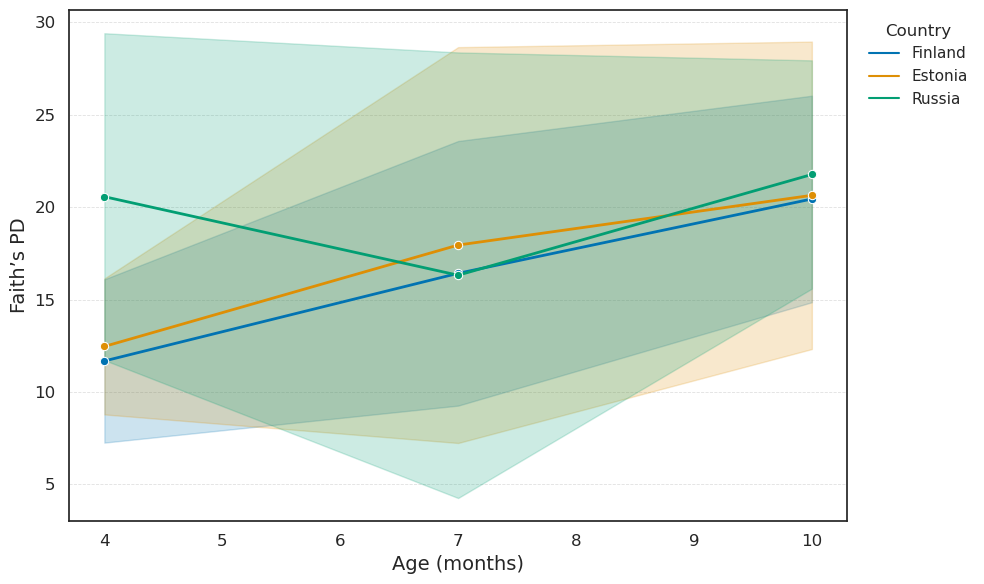

In [45]:
# Extra analysis: Faith's PD vs age (grouped by country)

# Load metadata and Faith's PD values
metadata = pd.read_csv(f"{raw_data_dir}/metadata.tsv", sep="\t")
faith_pd = pd.read_csv(
    f"{alpha_metrics_dir}/faith_pd_vector_export/alpha-diversity.tsv",
    sep="\t"
)

# Clean column names and merge tables
faith_pd = faith_pd.rename(columns={"Unnamed: 0": "id", "faith_pd": "Faith_PD"})
merged = metadata.merge(faith_pd, on="id")

# Plot settings
sns.set_theme(style="white")
plt.figure(figsize=(10, 6))

# Line plot
sns.lineplot(
    data=merged.sort_values("age_months"),
    x="age_months",
    y="Faith_PD",
    hue="geo_location_name",
    estimator="median",
    errorbar=("sd", 1),
    marker="o",
    markersize=6,
    linewidth=2,
    palette="colorblind"
)

# Styling
plt.grid(axis="y", linestyle="--", linewidth=0.6, color="lightgray", alpha=0.7)
plt.grid(axis="x", visible=False)
plt.xlabel("Age (months)", fontsize=14)
plt.ylabel("Faith’s PD", fontsize=14)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)

# Legend outside the plot
plt.legend(
    title="Country",
    frameon=False,
    loc="upper left",
    bbox_to_anchor=(1.01, 1)
)

plt.tight_layout()
plt.show()